### Résumé des fonctions de création et d'itération NumPy

| Fonction | Arguments principaux | Type de retour | Description |
| :--- | :--- | :--- | :--- |
| **`linspace`** | `start, stop, num` | `numpy.ndarray` | Génère `num` valeurs réparties uniformément entre `start` et `stop`. |
| **`logspace`** | `start, stop, num, base` | `numpy.ndarray` | Valeurs réparties uniformément sur une échelle logarithmique. |
| **`arange`** | `start, stop, step` | `numpy.ndarray` | Génère des valeurs de `start` à `stop` (exclu) avec un pas fixe `step`. |
| **`empty`** | `shape, dtype` | `numpy.ndarray` | Crée un tableau de forme `shape` sans initialiser les valeurs. |
| **`zeros`** | `shape, dtype` | `numpy.ndarray` | Crée un tableau de forme `shape` rempli de zéros. |
| **`enumerate`** | `iterable, start` | `iterator` | Retourne un itérateur de tuples contenant `(index, valeur)`. |

# Introduction to classification

Un classificateur est dit précis s’il est au moins meilleur qu’une estimation aléatoire.

L'objectif de ce TP est d'apprendre un modèle prédictif de qualité de vins en utilisant les caractéristiques physico-chimiques. On dispose d'une base de données telle que les variables d'entrée correspondent aux caractéristiques des vins et la variable de sortie à la catégorie des vins (bonne/mauvaise qualité)

In [122]:
from sklearn.neighbors import KNeighborsClassifier
# pour obtenir l'aide en ligne:
?KNeighborsClassifier

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

## Data analysis

### Chargez les données et affichez leur résumé. Combien d'échantillons et d'entrées avons-nous ?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
link = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

In [3]:
# header="infer": quand la première ligne du fichier contient le nom des colonnes
# header=None: quand la première ligne du fichier contient directement un sample
df = pd.read_csv(link, header="infer", delimiter=";")

In [4]:
# résumé des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


**Sample(=échantillon)**: Une observation individuelle (une ligne du tableau). En supervisé, il comprend l'input et son label.  
**Input(=entrée)**: L'ensemble des données numériques ou textuelles transmises au modèle pour effectuer une prédiction.  
**Label(=étiquette/classe)**: La réponse attendue (la cible). Il peut s'agir d'une classe (catégorie) ou d'une valeur numérique.   
**Caractéristiques(=features)**: Les propriétés ou variables utilisées par le modèle pour comprendre et prédire le label.  

Ici, il a 4898 entries, soit 4898 samples, les inputs correspondent à toutes les caractéristiques utiles à la prédiction (de fixed acidity à alcohol), il y a en 11, et la colonne qu'on souhaite prédire est quality, il y a donc 1 label.

In [5]:
# visualisation des premiers samples du dataset
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


axis=0: lignes  
axis=1: colonnes

Nous organisons les données sous forme de matrices et vecteurs pour le modèle :

* **Matrice d'entrée $X \in \mathbb{R}^{N \times d}$** : 
    * $N$ représente le nombre d'échantillons (**samples**).
    * $d$ représente le nombre de caractéristiques (**features**).
* **Vecteur de sortie $Y \in \mathbb{R}^N$** :
    * Contient les labels (la qualité du vin) pour chaque échantillon.

### Quelles sont les qualités du vin et le nombre d'échantillons correspondants ?

In [6]:
# X correspond aux inputs du modèle
# on retire la colonne qualité de X
X = df.drop("quality", axis=1)
# Y correspond aux labels que le modèle doit prédire
# Y est donc uniquement un vecteur qui est la colonne qualité
Y = df["quality"]

In [7]:
# nombre de samples par label
Y.value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

Il y a 7 labels, allant de 3 à 9. On a donc un problème de régrssion, mais on se ramène à un problème de classification binaire: si le vin est de qualité inférieure ou égale à 5, alors il est de mauvaise qualité (classe 0), sinon il est de bonne qualité (classe 1).

### Pour formuler un problème de classification binaire, nous regroupons les données par niveau de qualité.  
### Vérifiez le nombre d'échantillons par classe (nous avons maintenant les classes 0 et 1).

In [8]:
# retourne un array de 0 ou 1 (conversion en array plus fiable que list)
Y = np.array([0 if val <= 5 else 1 for val in Y])

In [9]:
# unique: retourne les valeurs uniques de Y (ici: [0,1])
# counts: compte le nombre de fois ou la valeur unique apparaît
unique, counts = np.unique(Y, return_counts = True)

# zip: combine les deux arrays élément par élément
# avec la boucle, on parcourt chaque paire (classe, nombre)
for u, c in zip(unique, counts):
    print(f"Classe {u}: {c} échantillons")

Classe 0: 1640 échantillons
Classe 1: 3258 échantillons


### 4. Effectuez une analyse statistique (moyenne, variance, corrélation…) des variables d’entrée.

**Boîtes à moustache (boxplot)**

/tmp/ipykernel_20449/3006545870.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


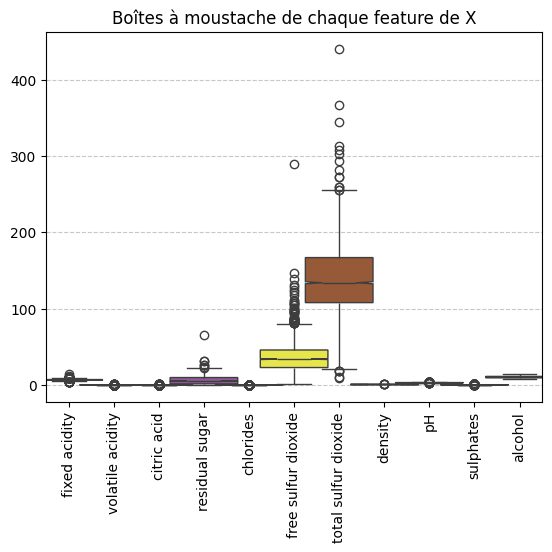

In [10]:
# créé une figure de plot
plt.figure()
# récupère les axes du graphique
ax = plt.gca()
# trace les boîtes à moustache (boxplot)
# notch=True: représente un intervalle de confiance (généralement à 95 %) autour de la médiane, effet "sablier"
sns.boxplot(data=X, orient='v', palette="Set1", width=1.5, notch=True)
ax.set_title("Boîtes à moustache de chaque feature de X")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7);

L'affichage des boîtes à moustaches sur les données brutes n'est pas pertinent, car les différences d'échelles entre les variables masquent les informations essentielles. Les caractéristiques ayant des valeurs élevées (comme le dioxyde de soufre) écrasent visuellement celles ayant des valeurs faibles (comme l'acidité), rendant leur distribution illisible. Pour remédier à cela, **il est nécessaire de centrer et réduire (normaliser) la matrice $X$**:  
$$
X_{\text{norm}} = \frac{X - \text{μ}}{\text{σ}}
$$

μ: moyenne  
σ: écart-type

Ainsi, le boxplot permet de:
- comparer la dispersion de chaque feature sur une échelle commune.
- identifier les outliers (points aberrants) de manière uniforme pour toutes les variables.

In [11]:
from sklearn.preprocessing import StandardScaler

/tmp/ipykernel_20449/34294782.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


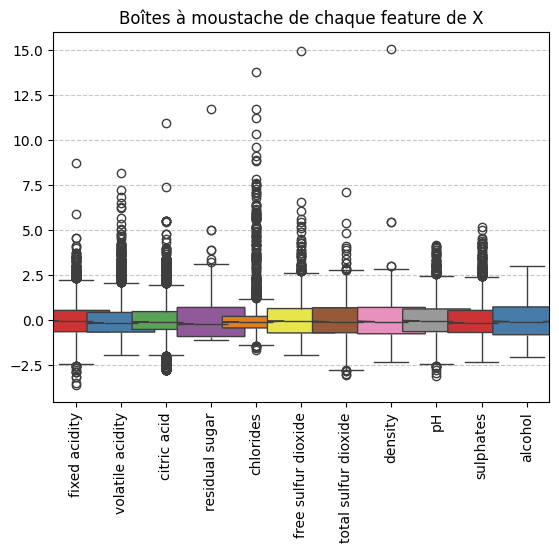

In [12]:
# objet StandardScaler pour normaliser 
scaler = StandardScaler()
# normalise X
X_norm = scaler.fit_transform(X)
# scaler retourne un array, on re-transforme X_norm en dataset
# reconstruction du dataframe: cela permet notamment de récupérer le nom des features de X
X_norm = pd.DataFrame(X_norm, columns=X.columns)

# créé une figure de plot
plt.figure()
# récupère les axes du graphique
ax = plt.gca()
# trace les boîtes à moustache (boxplot)
sns.boxplot(data=X_norm, orient='v', palette="Set1", width=1.5, notch=True)
ax.set_title("Boîtes à moustache de chaque feature de X")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7);

Toutes les features ont leur moyenne centrée en 0 et leur écart-type ramené à 1. Les différences d'échelles ne sont plus visibles. On constate que les données sont très étalées au-dessus de Q3, cela peut avoir un effet négatif sur certains modèles. En effet, des modèles comme la Régression Linéaire ou LDA sont sensibles aux valeurs aberrantes car ils "tirent" la moyenne vers le haut et peuvent fausser la droite de prédiction.

On pourrait même dans certains cas utiliser le RobustScaler qui ne se laissent pas influencer par les valeurs aberrantes:  
$$
X_{\text{robust}} = \frac{X - \text{médiane}}{\text{IQR}}
$$

In [13]:
# from sklearn.preprocessing import RobustScaler
# scaler_robust = RobustScaler()
# X_robust = scaler.fit_transform(X)

**Matrice de corrélation**

La matrice de corrélation permet d'évaluer la force des relations linéaires entre les variables.

Chaque élément $R_{i,j}$ de la matrice représente le coefficient de corrélation entre la caractéristique $i$ et la caractéristique $j$ :

$$R_{i,j} = \frac{\text{Cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}}$$

Où :
* $\text{Cov}(X_i, X_j)$ est la covariance entre les deux variables.
* $\sigma_{X_i}$ et $\sigma_{X_j}$ sont leurs écarts-types respectifs.

Si la matrice $X$ a été préalablement **centrée et réduite** (chaque colonne a une moyenne de 0 et une variance de 1), la matrice de corrélation se calcule très simplement via le produit matriciel :

$$R = \frac{1}{N} X^T X$$

Où :
* $X^T$ est la matrice transposée de $X$.
* $N$ est le nombre total d'échantillons (**samples**).

In [14]:
# matrice de corrélation à la main:
# N = X_norm.shape[0]
# corr_manual = (X_norm.T @ X_norm) / N
# sns.heatmap(corr_manual);

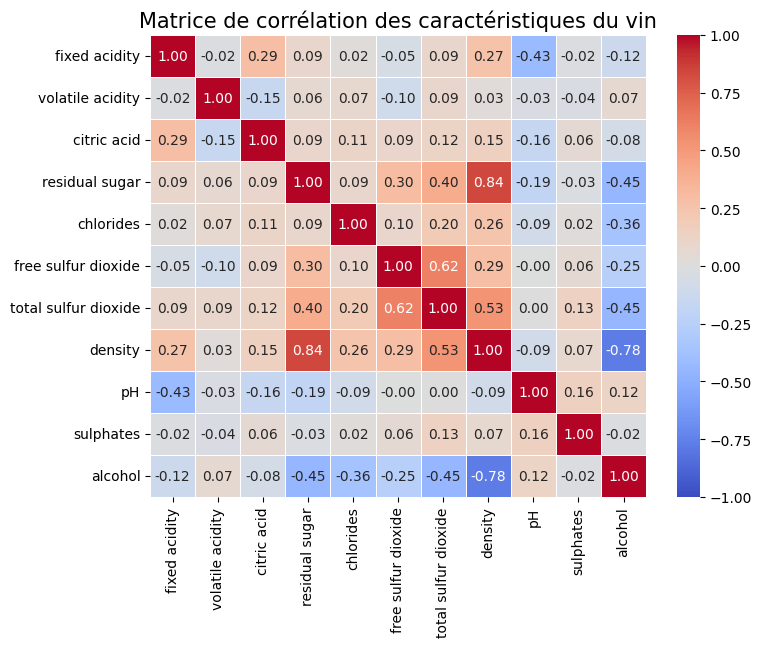

In [15]:
# matrice de corrélation:
plt.figure(figsize=(8, 6))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matrice de corrélation des caractéristiques du vin", fontsize=15);

- Corrélations positives fortes : On observe une relation très étroite entre density et residual sugar ($0.84$), ainsi qu'entre free sulfur dioxide et total sulfur dioxide ($0.62$). C'est logique : plus il y a de sucre, plus le liquide est dense, et les deux mesures de soufre sont chimiquement liées.  
- Corrélations négatives marquées : La variable alcohol est fortement corrélée négativement avec la density ($-0.78$). Cela s'explique physiquement : l'alcool est moins dense que l'eau ; donc, plus un vin est alcoolisé, plus sa densité baisse.
- Redondance potentielle : La forte corrélation entre la densité et le sucre ($0.84$) suggère qu'une de ces deux variables pourrait être supprimée si on souhaite simplifier le modèle sans perdre trop d'information.

## Classification

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

On a un dataset (X,Y) qu'on divise en trois parties:
- **Training set (Da=Xa,Ya): pour l'entraînement du modèle.**
C'est la base de données principale que le modèle "voit" et utilise pour apprendre. Le modèle ajuste ses paramètres internes (poids et biais) en essayant de minimiser l'erreur entre ses prédictions et les vrais labels.
- **Validation set (Dv=Xv,Yv): pour ajuster les hyperparamètres.**  
Utilisé pour ajuster les hyperparamètres et surveiller le risque de surapprentissage (overfitting). On évalue le modèle sur cet ensemble plusieurs fois pendant l'entraînement. Il sert à choisir la "meilleure version" du modèle avant l'étape finale.
- **Test set (Dt=Xt,Yt): pour évaluer la performance du modèle de prédiction.**  
Permet d'évalué la performance finale et réelle du modèle sur des données qu'il n'a jamais rencontrées (ni pendant l'entraînement, ni pendant la validation). On ne l'utilise qu'une seule fois, tout à la fin. Il donne une estimation honnête de la capacité du modèle à généraliser dans la vie réelle.

In [139]:
# D'abord on divise les données entre le Training set et le Test set
# shuffle=True: mélange des samples avant de les diviser
# test_size=1/3: 1/3 des données pour le Test, 2/3 pour le Training
# stratify=Y: conserve la proportion des classes
Xa, Xt, Ya, Yt = train_test_split(
    X, Y, shuffle=True, test_size=1/3, stratify=Y)

# Puis on divise les données entre le Training set et le Test set
# d'ou test_size = 0.5
Xa, Xv, Ya, Yv = train_test_split(
    Xa, Ya, shuffle=True, test_size=0.5, stratify=Ya)

On mélange les données (shuffle) pour:
- éviter les biais d'ordre: les données sont souvent collectées ou triées par groupe (ex: tous les vins de haute qualité au début du fichier) donc si on ne mélange pas, le modèle pourrait ne jamais voir certaines catégories.
- généraliser: le mélange garantit que les sous-ensembles d'entraînment et de test sont représentatifs de la diversité globale du dataset.

On conserve les proportions (stratify) pour:
- la représentativité: si le dataset contient 80% de vins rouges et 20% de vins blancs, le jeu d'entraînement et de tests doivent respecter ce même ratio.
- éviter le "hasard malheureux": sans stratify, un tirage aléatoire pourrait créer un jeu de tests dans aucune classe minoritaire ce qui rendrait l'évaluation de la performance sur  cette classe impossible.
- stabilité des métriques: cela permet d'obtenir des scores de performance plus cohérents et moins dépendantes du découpage.

### Modèle de prédiction: k-Nearest Neighbors (k-NN)

L'algorithme **k-NN** (*k-Nearest Neighbors*) utilise les échantillons du jeu de données $\mathcal{D}_a = (X_a, y_a)$ comme données de référence. 

#### Principe de prédiction
Pour un échantillon donné $x_i$, l'étiquette prédite correspond à la **majorité des étiquettes** de ses $k \in \mathbb{N}$ voisins les plus proches au sein de $(X_a, y_a)$.

#### Mesure de proximité
Les "voisins" sont les échantillons les plus proches de $x_i$ au sens de la **distance euclidienne**. Pour tout $x_j \in \mathcal{D}_a$, la distance au carré est définie par :

$$d(x_i, x_j)^2 = \|x_i - x_j\|^2 = (x_i - x_j)^T (x_i - x_j)$$

Où :
* $x_i$ est l'échantillon à prédire.
* $x_j$ est un échantillon appartenant au jeu de données d'apprentissage $\mathcal{D}_a$.
* $k$ est le nombre de voisins consultés pour le vote.

On considère chaque vin comme un point dans un espace à 11 dimensions, plus les valeurs de chaque feature sont proches et plus les vins sont similaires.

**k est un hyperparamètre**, il faut choisir combien de voisins regarder:
- k petit: modèle très complexe qui "colle" aux données. Il est sensible au bruit et aux erreurs de mesure, ce qui mène au surapprentissage (overfitting).
- k grand: modèle très simple et stable. Il ignore les détails locaux au profit d'une tendance trop globale, ce qui peut mener au sous-apprentissage (underfitting).

Choix de k:
1) on teste plusieurs valeurs impaires de k (pour éviter les situations d'égalité).
2) on calcule l'erreur sur le set de validation.
3) on choisit le k qui donne la plus petite erreur sur la validation (et non l'entraînement).

Pour prédire n'importe quel point de $X_v$, le modèle regarde uniquement derrière lui vers $X_a$ (les données qu'il a "apprises"), jamais à côté vers les autres points de $X_v$.

In [140]:
# choix arbitraire de l'hyperparamètre k, on regarde les 3 voisins les plus proches
k = 3
# créé un classifier k-NN, distance euclidienne par défaut
clf = KNeighborsClassifier(n_neighbors=k)
# "Entraînement": Le modèle mémorise les échantillons de référence (Xa) et leurs labels (Ya)
clf.fit(Xa,Ya)
# Prédiction : Pour chaque point de Xv, le modèle cherche les k plus proches voisins dans Xa 
# et prédit la classe majoritaire parmi leurs labels Ya
Ypred_v = clf.predict(Xv)

Ce qui se passe:  
- On prend un point de validation 
xi∈Xv  
- On le compare à tous les points de Xa pour trouver les k plus proches voisins.  
- On décide sa classe selon la majorité de ces voisins.  
- Puis on passe au point suivant de Xv et on recommence.  
-- -
* Chaque prédiction est indépendante.  
* Les points de validation ne sont jamais inclus dans l’ensemble d’entraînement.  
* Le modèle reste basé uniquement sur Xa, Ya, ce qui est important pour éviter de tricher sur la validation.  

**Matrice de confusion**  
Outil qui permet de mesurer la qualité d'un modèle de classification.  Elle ne se contente pas de dire si le modèle a raison ou tort, elle montre précisément quelles erreurs il commet.  C'est un tableau carré qui croise les classes réelles (les vraies étiquettes du set de validation) et les classes prédites par le modèle.  
Utilise car l'accuracy (% de bonnes prédictions) peut être trompeuse.  
Ex: 95% de vins rouges et 5% de vins blancs. Un modèle qui dit "tout est rouge" aura 95% d'accuracy mais il est nul pour détecter le blanc. La matrice de confusion montre immédiatement qu'il a 0 bonne réponse pour les blancs.

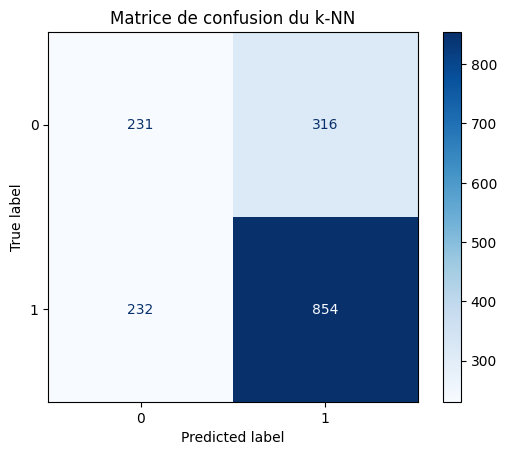

In [141]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Création de la matrice
cm = confusion_matrix(Yv, Ypred_v)

# Affichage visuel
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Matrice de confusion du k-NN")
plt.show()

**Taux d'erreur**

In [142]:
from sklearn.metrics import accuracy_score
error_v = 1 - accuracy_score(Yv, Ypred_v)

In [143]:
print(f"Erreur de validation (k={k}) : {error_v:.4f}")

Erreur de validation (k=3) : 0.3356


Résultat: environ 31.5% des prédictions sont incorrects: le modèle n'est pas parfait pour k=3, mais il fait quand même mieux que le hasard si les classes sont équilibrées.

Entraînement du k-nn classifier pour différentes valeurs de k

In [144]:
# créé une liste régulièrement espacé (start, stop, step)
# 1: point de départ
# 37: point d'arrêt (exclu)
# 2: le pas (intervalle entre chaque nombre, ici on a: 1,3,5,7...,35]
k_vector = np.arange(1,37,2)
# np.empty: génère un tableau vide de même taille que k_vector
error_train = np.empty(k_vector.shape)
error_val = np.empty(k_vector.shape)

# enumerate retourne à la fois l'indice et la valeur actuel
# for index, value de iterable
# k prend successivement les valeurs définis dans k_vector
# ind: 0 (k=1) puis 1 (k=3) puis 2 (k=5) ...
for ind, k in enumerate(k_vector):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(Xa,Ya)
    # prédit les labels des points que le modèle a déjà vus
    # le point xi de Xa lui-même compte parmi les plus proches voisins de xi
    # donc si k=1 ici, le modèle est parfait puisque le point est son propre voisin
    # cependant ça ne sert à rien car ça ne permet pas de généraliser à de nouvelles données
    Ypred_train = clf.predict(Xa)
    error_train[ind]= 1 - accuracy_score(Ya, Ypred_train)
    
    # prédit les labels des points que le modèle n'a jamais vu
    # => à quel point le modèle généralise à de nouvelles données
    Ypred_val = clf.predict(Xv)
    error_val[ind]= 1 - accuracy_score(Yv, Ypred_val)

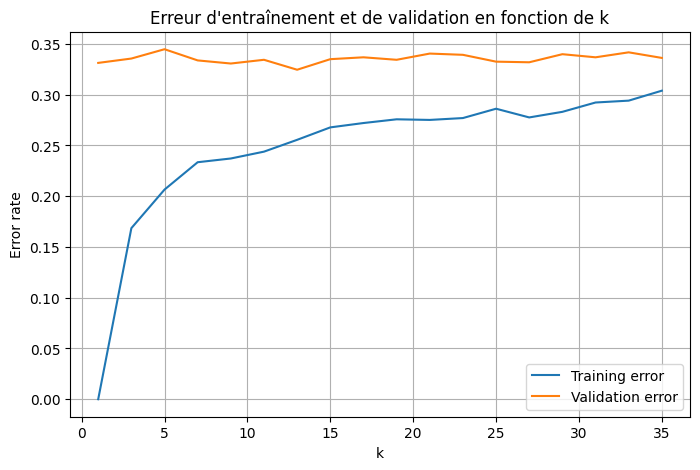

In [145]:
plt.figure(figsize=(8,5))
plt.plot(k_vector, error_train, label='Training error')
plt.plot(k_vector, error_val, label='Validation error')
plt.xlabel("k")
plt.ylabel("Error rate")
plt.title("Erreur d'entraînement et de validation en fonction de k")
plt.legend()
plt.grid(True)
plt.show()

- Le piège du $k=1$ : L'erreur d'entraînement est nulle car le modèle mémorise ses propres points, mais l'erreur de validation reste élevée et instable, signe d'un fort surapprentissage (overfitting).
- Défaut de généralisation : La stagnation de l'erreur de validation entre 0.30 et 0.34 montre que le modèle peine à s'adapter à de nouvelles données.
- Le choix de la stabilité : Bien que $k=1$ soit le minimum mathématique, un creux vers $k=29$ est préférable car les courbes y sont plus proches, garantissant un modèle plus robuste et moins sensible au bruit.

- Training error << Validation error => le modèle est trop flexible: overfitting (sur-apprentissage)
- Training error ~ Validation error => le modèle généralise bien
- Traing error >> Validation error => le modèle est trop simple: underfitting (sous-apprentissage)

In [146]:
# meilleur valeur de k (k*) basée sur Validation error
error_min, ind_opt = error_val.min(), error_val.argmin()
k_star = k_vector[ind_opt]
print(f"meilleur valeur de k: {k_star}")

meilleur valeur de k: 13


In [147]:
# On ignore les premières valeurs (ex: les 3 premières) pour éviter l'overfitting du k=1
# On cherche l'index du minimum dans le reste du vecteur
# +3 car on a enlever les 3 premières valeurs, cela permet de recaler l'index
ind_opt = error_val[3:].argmin() + 3

k_star = k_vector[ind_opt]
print(f"Meilleur valeur de k (après filtrage de l'overfitting) : {k_star}")

Meilleur valeur de k (après filtrage de l'overfitting) : 13


- Performance : Le modèle k-NN sur données non normalisées échoue dans environ 33 % des cas (1 vin sur 3).
- Problème identifié : L'erreur de validation est instable et élevée, indiquant que le modèle peine à généraliser.

Améliorations possibles:
- Normalisation: Le k-NN calcule des distances. Sans normalisation, les variables à forte échelle (ex: soufre) écrasent les autres (ex: pH). Standardiser $X$ permet de donner le même "poids" à chaque caractéristique.
- Sélection de $k$: Éviter $k=1$ (surapprentissage) et privilégier un $k$ plus grand (ex: $k=29$) où l'erreur est plus stable, même si le score d'entraînement est moins bon.
- Complexité du modèle: Si la normalisation ne suffit pas, il faut tester des algorithmes plus puissants (comme Random Forest), car la relation entre les composants du vin et sa qualité n'est peut-être pas simplement basée sur la proximité géométrique.

## Normalize the data

In [148]:
sc = StandardScaler(with_mean=True, with_std=True)

# il est mieux de fit sur Xa puis appliquer sur les autres données, sinon on aurait une fuite de données !
# c'est le fait d'intégrer des informations provenant du futur (le test) dans le présent (l'entraînement) lors 
# du traitement des données.
sc = sc.fit(Xa)

Xa_n = sc.transform(Xa)
Xv_n = sc.transform(Xv)

# on ne normalise pas Ya et Yv ! 

**On normalise les données après avoir divisé les données** car sinon on aurait calculé la moyenne et l'écart-type sur toutes les données, y compris celles des futurs test/validation set, ce qui aurait introduit une fuite de données: le modèle "voit" indirectement des informations sur le dataset donc l'évaluation n'est plus réaliste.

On reprend la même démarche que précedemment pour les données normalisées

In [149]:
k_vector = np.arange(1,37,2)
error_train = np.empty(k_vector.shape)
error_val = np.empty(k_vector.shape)

for ind, k in enumerate(k_vector):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(Xa_n,Ya)
    Ypred_train = clf.predict(Xa_n)
    error_train[ind]= 1 - accuracy_score(Ya, Ypred_train)
    
    Ypred_val = clf.predict(Xv_n)
    error_val[ind]= 1 - accuracy_score(Yv, Ypred_val)

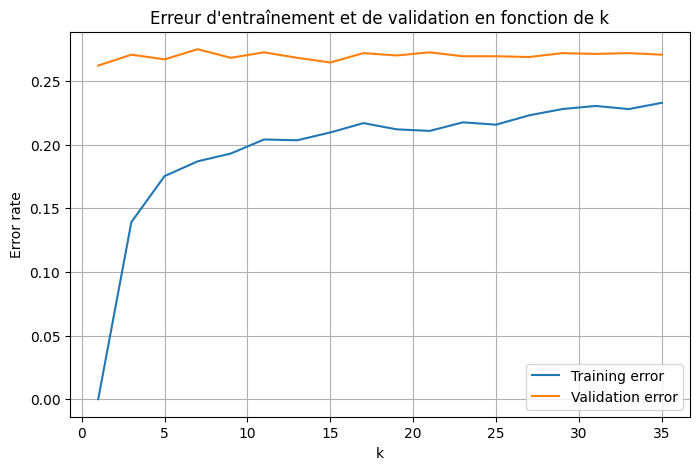

In [150]:
plt.figure(figsize=(8,5))
plt.plot(k_vector, error_train, label='Training error')
plt.plot(k_vector, error_val, label='Validation error')
plt.xlabel("k")
plt.ylabel("Error rate")
plt.title("Erreur d'entraînement et de validation en fonction de k")
plt.legend()
plt.grid(True)
plt.show()

Grâce à la normalisation, ce nouveau graphique affiche un comportement bien plus sain: la courbe de validation est plus stable, l'erreur globale a chuté de 33% à 25%, et le meilleur $k$ n'est plus le piège du $k=1$, mais une valeur ($k=9$) qui garantit une bien meilleure généralisation du modèle.

In [151]:
error_min, ind_opt = error_val.min(), error_val.argmin()
k_star = k_vector[ind_opt]
print(f"meilleur valeur de k: {k_star}")

meilleur valeur de k: 1


On a une Validation error moyenne d'environ 25% avec normalisation des données, ce qui a fait baisser le taux d'erreur d'environ 7%, on a même un meilleur k qui fournit une Validation error d'environ 24%. Donc le modèle se trompe 1 fois sur 4, c'est déjà mieux que 1 fois sur 3!  
Conclusion: il faut normaliser les données.

### How to make the trained models less sensitive to the data split ?

Pour ne plus dépendre de la "chance" lors du mélange initial des données, on utilise principalement la **Validation Croisée (Cross-Validation)**:
- Le principe (K-Fold) : Au lieu de diviser les données en deux blocs fixes (Train/Val), on découpe le dataset en $K$ morceaux (ex: 5 ou 10). On entraîne et on valide le modèle $K$ fois, en changeant de morceau de validation à chaque fois.
- L'objectif : On calcule ensuite la moyenne des performances sur ces $K$ essais. Cela donne une vision beaucoup plus robuste et "honnête" de la qualité du modèle.
- La Stratification : On s'assure que chaque morceau contient toujours la même proportion de chaque classe (ex: même % de vins de qualité 5, 6, 7) pour éviter qu'un découpage ne soit déséquilibré.

En résumé, la validation croisée permet d'utiliser l'intégralité des données pour l'entraînement et la validation, ce qui stabilise le choix de l'hyperparamètre $k$ et garantit que le modèle fonctionnera bien sur n'importe quel nouvel échantillon.

### Elements de cours
**Loss function**: mesure l’erreur entre la prédiction et la vérité. On veut minimiser la valeur de la fonction de perte.
* k-NN: pas de loss function
* Linear Regression -> MSE (quadratic) 
* Logistic Regression -> Cross-entropy
* SVM -> Hinge loss
* Random Forest -> impureté de Gini

Étant donné que l’entraînement repose sur un ensemble fini de données, un modèle peut être sujet au sur-apprentissage (overfitting). Ce phénomène survient lorsque le modèle présente de très bonnes performances sur les données d’entraînement, mais une capacité de généralisation insuffisante, se traduisant par de mauvaises performances sur des données de test non observées.

**Overfitting**: Train error très bas et Test error élevé.  
Cela se produit lorsqu'un modèle apprend trop bien les données d'entraînement, y compris le bruit (erreurs, valeurs aberrantes) et les détails très spécifiques.  
=> fonctionne très bien sur les données Xtrain, mais généralise mal pour les données Xtest.
En général, on remarque que les deux  courbes baissent puis celle de Test error remonte alors que Train error baisse toujours.
=> Le minimum de la courbe test correspond au meilleur modèle.   

Analogie: on souhaite apprendre à reconnaître les chiens et les chats.  
Bon apprentissage: le modèle retient les caractéristiques générales.
Surraprentissage: le modèle retient même la position exacte de la tâche sur le poil de chaque animal de Xtrain => impossible de reconnaître un nouveau chien car il n'aura pas ses mêmes tâches.

**Underfitting**: Train error élevé et Test error élevé: le modèle est trop simple.

**Supervised learning**: on veut apprendre une fonction de prédiction y = f(x) à partir de données avec labels. On a (x,y) avec x: données d’entrées et y: labels. C’est-à-dire que le modèle apprend avec des exemples dont il connaît déjà la bonne réponse. Il essaye à partir de là de corriger les erreurs.
Je fais une prédiction → je compare à la vérité → je corrige
Ex: Random Forest, Decision Tree, SVM, K-NN

**Unsupervised learning**: on cherche un pattern dans les données sans connaître les réponses à l’avance car les données n’ont pas de labels.
J’observe les données → je cherche une organisation qui les explique le mieux
Ex: K-means, Hierarchical Clustering, ACP

| Caractéristique | Régression | Classification |
| :--- | :--- | :--- |
| **Type de sortie** | Continue (Nombres)  | Discrète (Classes/Labels) |
| **Question posée** | "Combien ?" | "Lequel ?" ou "Est-ce que... ?" |
| **Exemple** | Prédire le poids d'un objet | Détecter un email comme "Spam" |